In [14]:
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from pathlib import Path
import scipy
from scipy.ndimage import gaussian_filter1d

In [2]:
# load data
grad = xr.open_dataset('NC_average_lat_lon_with_gradient.nc')

In [11]:
grad

<xarray.Dataset> Size: 843kB
Dimensions:  (site: 9579)
Coordinates:
  * site     (site) <U16 613kB 'usa_NC_0001_0001' ... 'usa_NC_0049_0230'
    lat      (site) float64 77kB ...
    lon      (site) float64 77kB ...
Data variables:
    grad     (site) float64 77kB nan 486.2 477.9 469.7 ... -802.9 -826.1 nan

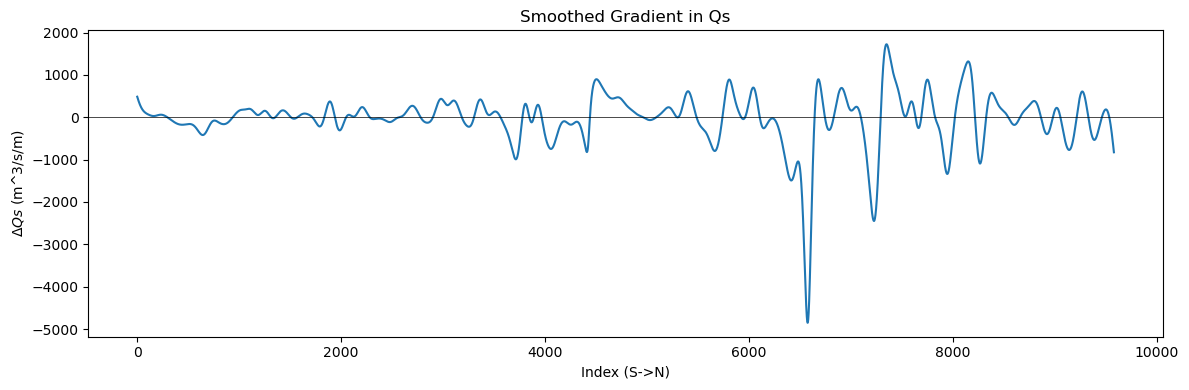

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(grad['grad'])
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Index (S->N)")
ax.set_ylabel(f"$\Delta Qs$ (m^3/s/m)")
ax.set_title(f"Smoothed Gradient in Qs")
plt.tight_layout()
plt.show()

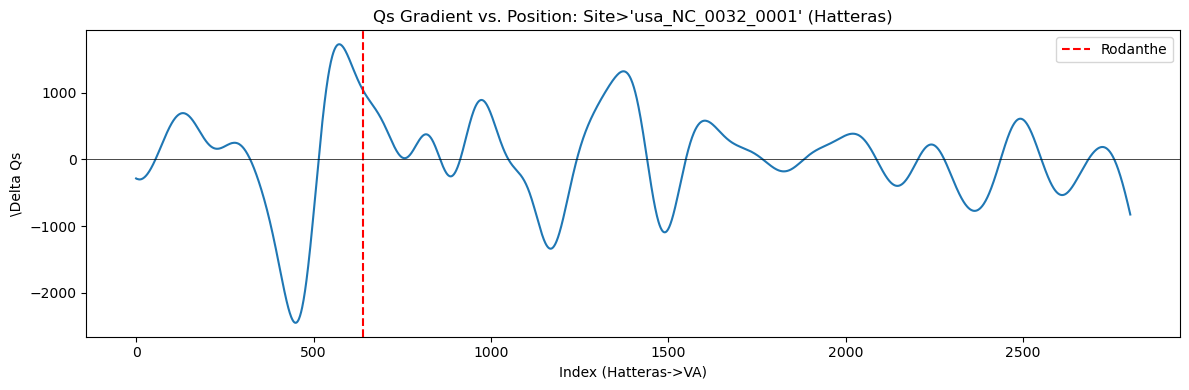

In [17]:
# just for nobx
target_site = 'usa_NC_0032_0001'
start_idx = np.where(grad['site'].values == target_site)[0][0] + 200

rodanthe_site = 'usa_NC_0036_0027'
rodanthe_idx = np.where(grad['site'].values == rodanthe_site)[0][0] - start_idx

grad_nobx = grad.isel(site=slice(start_idx, None))

# plot gradient along index
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(grad_nobx['grad'].values)
ax.axvline(x=rodanthe_idx, color='red', linestyle='--', label='Rodanthe')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel(f"\Delta Qs")
ax.set_title(f"Qs Gradient vs. Position: Site>'{target_site}' (Hatteras)")
plt.tight_layout()
plt.legend()
plt.show()

In [82]:
lrr = pd.read_csv('coastsat_lrr_obx_1984_2025.csv').set_index('transect_id')

d_eta = xr.Dataset(
    {'d_eta': ('site', lrr['lrr_m_yr'].reindex(grad_nobx['site'].values).values)},
    coords={
        'site': grad_nobx['site'].values,
        'lat': ('site', grad_nobx['lat'].values),
        'lon': ('site', grad_nobx['lon'].values),
    },
)

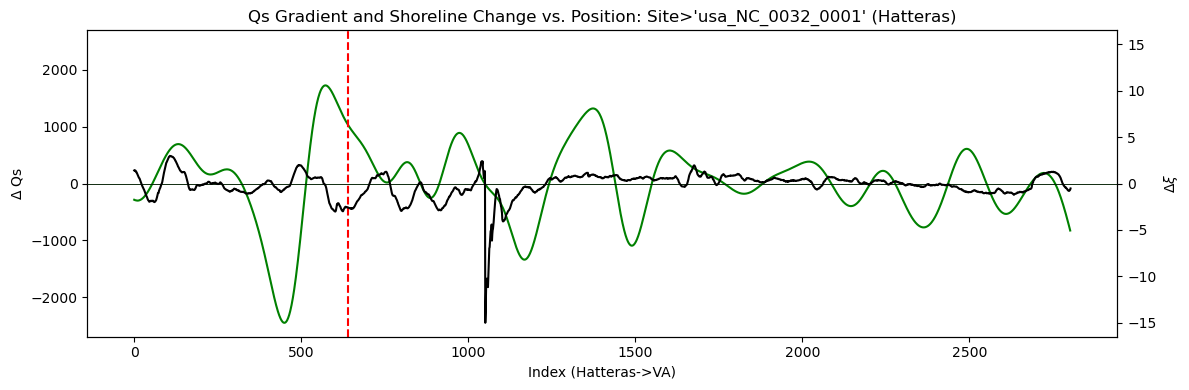

In [83]:
fig, ax = plt.subplots(figsize=(12, 4))
ax2 = ax.twinx()

l1, = ax.plot(grad_nobx['grad'].values, c='g', label=r'$\Delta$ Qs gradient')
l2, = ax2.plot(d_eta['d_eta'].values, c='k', label='Shoreline change (LRR)')
l3 = ax.axvline(x=rodanthe_idx, color='red', linestyle='--', label='Rodanthe')
ax.axhline(0, color='g', lw=0.5)
ax2.axhline(0, color='k', lw=0.5)

lim1 = np.nanmax(np.abs(grad_nobx['grad'].values))*1.1
lim2 = np.nanmax(np.abs(d_eta['d_eta'].values))*1.1
ax.set_ylim(-lim1, lim1)
ax2.set_ylim(-lim2, lim2)

ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel(r"$\Delta$ Qs", color='k')
ax2.set_ylabel(r"$\Delta \xi$", color='k')
ax.tick_params(axis='y', colors='k')
ax.set_title(f"Qs Gradient and Shoreline Change vs. Position: Site>'{target_site}' (Hatteras)")
plt.tight_layout()
plt.show()

In [84]:
d_eff = (grad_nobx['grad'] / d_eta['d_eta']).rename('d_eff')

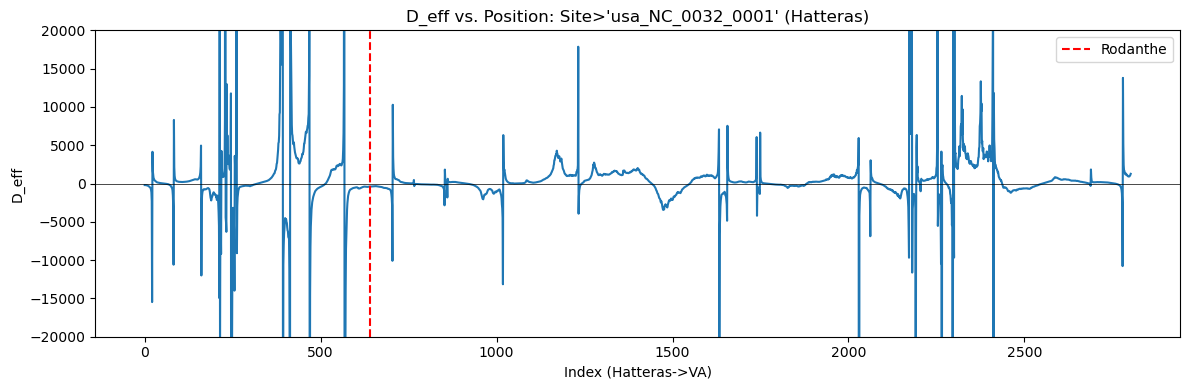

In [85]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(d_eff.values)
ax.axvline(x=rodanthe_idx, color='red', linestyle='--', label='Rodanthe')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel(f"D_eff")
ax.set_title(f"D_eff vs. Position: Site>'{target_site}' (Hatteras)")
ax.set_ylim([-20000,20000])
plt.tight_layout()
plt.legend()
plt.show()

In [86]:
d_eta_masked = d_eta['d_eta'].where(np.abs(d_eta['d_eta']) > .5)
d_eff_masked = (grad_nobx['grad'] / d_eta_masked).rename('d_eff')

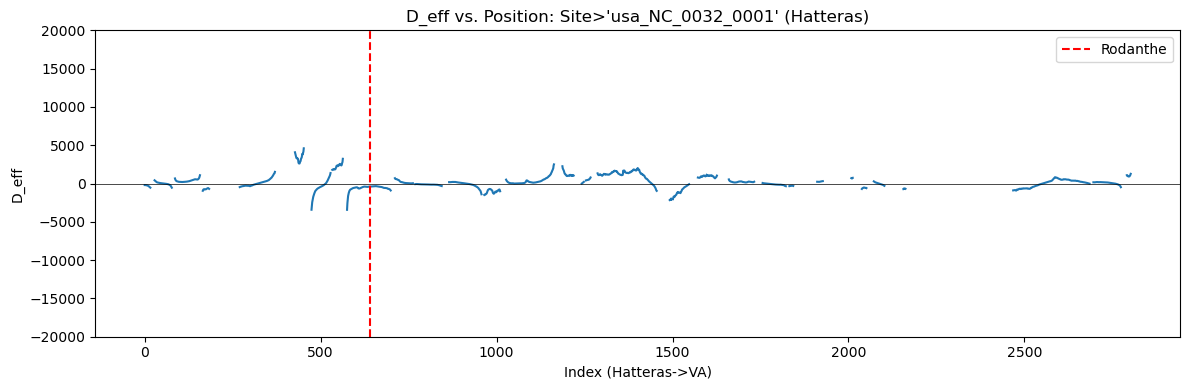

In [87]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(d_eff_masked.values)
ax.axvline(x=rodanthe_idx, color='red', linestyle='--', label='Rodanthe')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel(f"D_eff")
ax.set_title(f"D_eff vs. Position: Site>'{target_site}' (Hatteras)")
ax.set_ylim([-20000,20000])
plt.tight_layout()
plt.legend()
plt.show()

In [90]:
# cumulative along-shore distance (m) from d_eff's own lat/lon
lat_r = np.radians(d_eff_masked['lat'].values)
lon_r = np.radians(d_eff_masked['lon'].values)
a = (np.sin(np.diff(lat_r) / 2)**2
     + np.cos(lat_r[:-1]) * np.cos(lat_r[1:]) * np.sin(np.diff(lon_r) / 2)**2)
seg = 2 * 6371000.0 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
d_eff_masked = d_eff_masked.assign_coords(alongshore_m=('site', np.concatenate([[0.0], np.cumsum(seg)])))

# linear interpolation across gaps, but don't bridge gaps wider than max_gap meters
d_eff_interp = d_eff_masked.interpolate_na(dim='site', use_coordinate='alongshore_m', max_gap=10000)

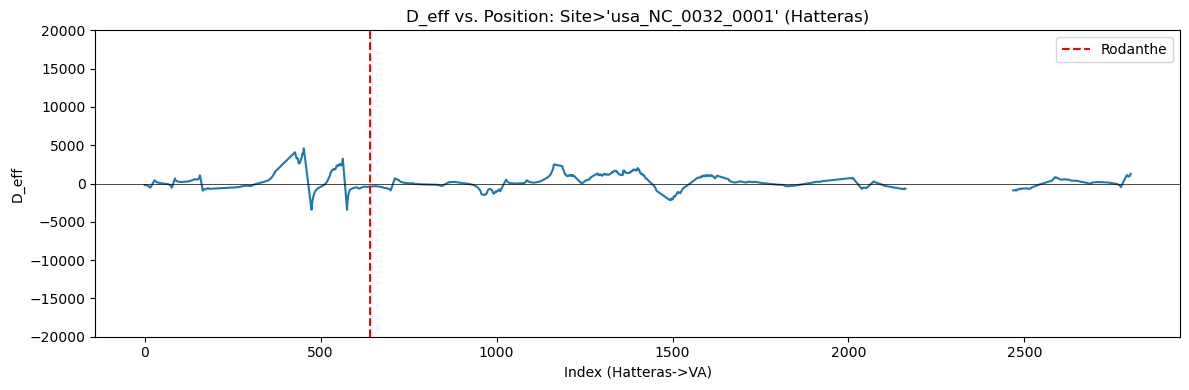

In [91]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(d_eff_interp.values)
ax.axvline(x=rodanthe_idx, color='red', linestyle='--', label='Rodanthe')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel(f"D_eff")
ax.set_title(f"D_eff vs. Position: Site>'{target_site}' (Hatteras)")
ax.set_ylim([-20000,20000])
plt.tight_layout()
plt.legend()
plt.show()

In [110]:
curv = xr.open_dataset('NC_average_lat_lon_with_curvature.nc')
diff = xr.open_dataset('ncmu_total_hourly_pertransect.nc', chunks={'time': 2000})
mean_diff = diff['mu'].mean(dim='time').compute()

/tmp/ipykernel_245209/3423008418.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 2000. This could degrade performance. Instead, consider rechunking after loading.
  diff = xr.open_dataset('ncmu_total_hourly_pertransect.nc', chunks={'time': 2000})


In [111]:
target_site = 'usa_NC_0032_0001'
start_idx = np.where(curv['site'].values == target_site)[0][0]+200

rodanthe_site = 'usa_NC_0036_0027'
rodanthe_idx = np.where(curv['site'].values == rodanthe_site)[0][0]-start_idx

curv_nobx = curv.isel(site=slice(start_idx, None))
mean_diff_nobx = mean_diff.isel(site=slice(start_idx, None))
diffusivity_nobx = mean_diff_nobx.values

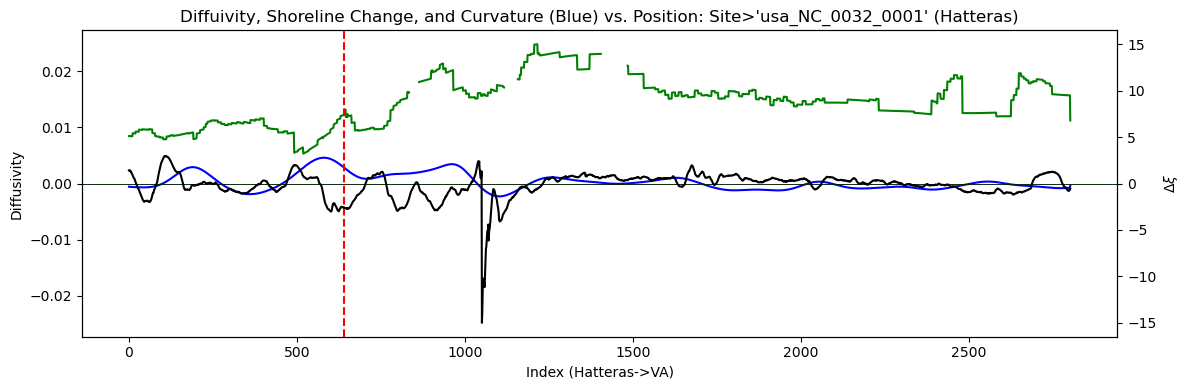

In [117]:
fig, ax = plt.subplots(figsize=(12, 4))
ax2 = ax.twinx()

l1, = ax.plot(diffusivity_nobx, c='g')
l2, = ax.plot(curv_nobx['curvature'].values*100, c='b')
l3, = ax2.plot(d_eta['d_eta'].values, c='k')
l4 = ax.axvline(x=rodanthe_idx, color='red', linestyle='--', label='Rodanthe')
ax.axhline(0, color='g', lw=0.5)
ax2.axhline(0, color='k', lw=0.5)

lim1 = np.nanmax(np.abs(diffusivity_nobx))*1.1
lim2 = np.nanmax(np.abs(d_eta['d_eta'].values))*1.1
ax.set_ylim(-lim1, lim1)
ax2.set_ylim(-lim2, lim2)

ax.set_xlabel("Index (Hatteras->VA)")
ax.set_ylabel("Diffusivity", color='k')
ax2.set_ylabel(r"$\Delta \xi$", color='k')
ax.tick_params(axis='y', colors='k')
ax.set_title(f"Diffuivity, Shoreline Change, and Curvature (Blue) vs. Position: Site>'{target_site}' (Hatteras)")
plt.tight_layout()
plt.show()